In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [2]:
X = pd.read_csv("../data/processed/scaled_features.csv")

In [3]:
isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

In [4]:
anomaly_labels = isolation_forest.fit_predict(X)

In [5]:
df = pd.read_csv("../data/raw/Housing.csv")

df["anomaly"] = anomaly_labels

In [6]:
df["anomaly"].value_counts()

anomaly
 1    517
-1     28
Name: count, dtype: int64

In [7]:
anomalies = df[df["anomaly"]== -1]

In [8]:
anomalies.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,anomaly
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,-1
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,-1
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,-1
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,-1
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished,-1


In [9]:
anomalies[
    [
        "price",
        "area",
        "bedrooms",
        "bathrooms",
        "stories",
        "parking"
    ]
].describe()

,price,area,bedrooms,bathrooms,stories,parking
count,2.800000e+01,28.000000,28.000000,28.000000,28.000000,28.000000
mean,7.289500e+06,6911.071429,3.642857,1.785714,2.285714,1.178571
std,3.052381e+06,3339.256137,0.826160,0.738223,1.013141,0.983327
min,2.233000e+06,2175.000000,2.000000,1.000000,1.000000,0.000000
25%,5.048750e+06,4725.000000,3.000000,1.000000,2.000000,0.000000
50%,7.087500e+06,6525.000000,4.000000,2.000000,2.000000,1.000000
75%,9.800000e+06,8175.000000,4.000000,2.000000,3.000000,2.000000
max,1.225000e+07,16200.000000,5.000000,4.000000,4.000000,3.000000


In [10]:
normal_properties = df[
    df["anomaly"] == 1
]

In [11]:
normal_properties[
    [
        "price",
        "area",
        "bedrooms",
        "bathrooms",
        "stories",
        "parking"
    ]
].describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.170000e+02,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.630099e+06,5055.193424,2.928433,1.259188,1.779497,0.667311
std,1.684284e+06,2050.440627,0.715758,0.472641,0.852337,0.847680
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3540.000000,2.000000,1.000000,1.000000,0.000000
50%,4.270000e+06,4500.000000,3.000000,1.000000,2.000000,0.000000
75%,5.600000e+06,6321.000000,3.000000,1.000000,2.000000,1.000000
max,1.330000e+07,15600.000000,6.000000,3.000000,4.000000,3.000000


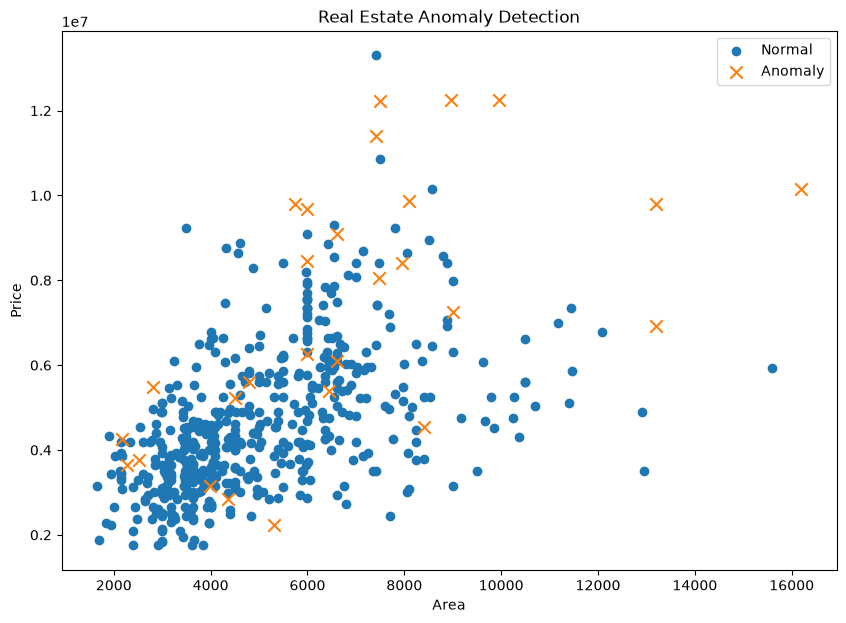

In [12]:
plt.figure(figsize=(10, 7))

plt.scatter(
    normal_properties["area"],
    normal_properties["price"],
    label="Normal"
)

plt.scatter(
    anomalies["area"],
    anomalies["price"],
    label="Anomaly",
    marker="x",
    s=80
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Real Estate Anomaly Detection")

plt.legend()
plt.show()

In [18]:
import joblib
from sklearn.metrics import silhouette_score

joblib.dump(
    isolation_forest,"../models/isolation_forest.pkl"
)

['../models/isolation_forest.pkl']

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    silhouette_scores.append(score)

print("K-Means Silhouette Scores:")
print(silhouette_scores)

c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

K-Means Silhouette Scores:
[0.163370623592944, 0.13709723273437405, 0.15263815400667258, 0.16534392909193626, 0.1720851264599224, 0.1753378399027116, 0.15448230930867304, 0.1650211213612036, 0.17728221948447342]


c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [24]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_scores = []

for k in range(2, 11):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    hierarchical_scores.append(score)

print("Hierarchical Silhouette Scores:")
print(hierarchical_scores)

Hierarchical Silhouette Scores:
[0.12293914223655014, 0.14521836063812663, 0.15436376631924856, 0.14200922165541555, 0.15301265867869035, 0.12603433397666952, 0.13818115056400776, 0.14111781539165444, 0.15197582406029736]


In [25]:
results = {
    "K-Means Silhouette": max(silhouette_scores),
    "Hierarchical Silhouette": max(hierarchical_scores)
}

results

{'K-Means Silhouette': 0.17728221948447342,
 'Hierarchical Silhouette': 0.15436376631924856}